# Critical core mass in giant planet formation

In the core accretion scenario of giant planet formation, large amounts of gas are accreted on a pre-existing solid core. In this notebook, we are going to build a simple numerical model of a giant planet and see how big we can make the core before the model breaks down.

## Setting up hydrostatic equilibrium

Consider a non-rotating, spherically symmetric planet with a core of mass $M_c$, core density of $\rho_c$ (i.e. the density of rock if the core is rocky, $\rho_c \sim 3000~\mathrm{kg~m^{-3}}$), and core radius $r_c$, surrounded by a gaseous envelope with density $\rho(r)$. If our planet is in hydrostatic equilibrium (pressure gradient balances gravity, see section 3.2 of FPS), the pressure gradient needs to satisfy: 
$$\frac{dP}{dr} = -\frac{G(M_c + M_e(r))\rho(r)}{r^2},$$
where $r$ is the spherical radial coordinate and $M_e(r)$ is the envelope mass inside $r$. The envelope mass can be found from the density:
$$\frac{dM_e}{dr} = 4\pi r^2 \rho(r).$$
Boundary conditions at the core surface $r=r_c$ are $M_e=0$ (the envelope starts at $r_c$!) and $dP/dr= -GM_c \rho_i/r_c^2$, where $\rho_i$ is the gas density at the core surface. We can eliminate $M_e$ to obtain a single equation:
$$\frac{d}{dr}\left(\frac{r^2}{\rho(r)}\frac{dP}{dr}\right) = -4\pi G r^2 \rho(r).$$

## Polytropes

We still have two unknowns, pressure and density. A realistic model would at this point introduce an energy conservation equation, and an equation of state relating pressure, temperature and density. An example would be the ideal gas equation of state, although deep inside gas giants gas is far from ideal. In this notebook, we take a simpler approach, often used in astrophysics: we postulate a polytropic equation of state, $P=K\rho^{1+1/n}$, for constants $K$ and $n$ (see FPS section 3.3.4). Since in this equation of state, pressure depends on density only, we end up with an equation for the density only:
$$K(n+1)\frac{d}{dr}\left(r^2\frac{d}{dr}\rho^{1/n}\right) = -4\pi G r^2 \rho(r).$$
If we define $\theta = (\rho/\rho_i)^{1/n}$ and $\xi=\alpha r$, where the constant $\alpha$ depends on $K$, $G$, $n$ and $\rho_i$, we arrive at the famous [Lane-Emden equation](https://en.wikipedia.org/wiki/Lane%E2%80%93Emden_equation):
$$\frac{d}{d\xi}\left(\xi^2\frac{d\theta}{d\xi}\right) = -\xi^2\theta^n.$$
Boundary conditions: $\theta=1$ at the core surface where $\xi=\xi_c$ and
$$\left.\frac{d\theta}{d\xi}\right|_{\xi=\xi_c} = -\frac{\xi_c \rho_c}{3\rho_i}.$$

## Numerical model

For a few values of $n$, analytic solutions exist to the Lane-Emden equation (in particular for $n=1$, see FPS section 3.3.4). However, we will construct a numerical model in Python. Since all boundary conditions are given at the core surface, we can solve it as an initial value problem.

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar, fsolve
import matplotlib.pyplot as plt

For gas giant planets, polytropes with $n=1$ work reasonably well, so we choose $n=1$. Numerical ODE solvers can only handle first order ODEs, so we have to rewrite our second-order equation as two first-order equations for $y_0=\theta$ and $y_1=d\theta/d\xi$:
$$y_0' = y_1,\\
  y_1' = -y_0^n - 2y_1/\xi,$$
with 'initial conditions' $y_0(\xi_c)=1$ and $y_1(\xi_c)=-\xi_c\rho_c/(3\rho_i)$. In addition, we can monitor the total envelope mass by adding a third equation:
$$y_2' = \xi^2y_0^n,$$
with $y_2 = M_e \alpha^3/(4\pi\rho_i)$ and 'initial condition' $y_2(\xi_c)=0$. The total mass contained within $\xi$ is
$$\frac{M}{M_c} = 1 + \frac{3\rho_i}{\rho_c} \frac{y_2(\xi)}{\xi_c^3}.$$

In [50]:
polytrope_index = 1.0

def rhs(t, y):
    '''Returns the right-hand side of our system of ODEs'''
    return [y[1], -np.power(y[0], polytrope_index) - 2*y[1]/t, t*t*np.power(y[0], polytrope_index)]

def outer_radius(t, y):
    '''Defines an event where y0=0 (density reaches zero), which defines the outer radius of the planet.'''
    return y[0]

def solve(xi_c, rho_i, fine_grained=False):
    '''Returns a solution to the initial value problem'''
    xi_c = np.atleast_1d(xi_c)
    xi_c = xi_c[0]

    t_eval = None
    if fine_grained is True:
        # Nice for plotting, but more expensive to run
        t_eval=np.linspace(xi_c, 100, 10000)
    sol = solve_ivp(rhs, [xi_c, 100], [1, -xi_c/(3*rho_i), 0], t_eval=t_eval, events=outer_radius)

    # In some cases (n=1.5 for example), the solver fails if the density becomes negative
    if sol.success is True:
        # If succeeded, planet radius is the first time we encounter zero density
        xi_out = sol.t_events[0][0]
        m_out = sol.y_events[0][0][2]
    else:
        # If failed, the radius is the last valid point
        xi_out = sol.t[-1]
        m_out = sol.y[2][-1]

    # Only return solution within planet radius
    sel = np.asarray(sol.t < xi_out).nonzero()
    return np.append(sol.t[sel], xi_out), np.append(sol.y[0][sel], 0.0), 3*rho_i*np.append(sol.y[2][sel],m_out)/xi_c**3 + 1


A solution is determined by two parameters: $\xi_c$ (essentially the core mass) and $\rho_i/\rho_c$ (the gas density at the core surface). To get a feel for what the solutions look like, let's make a few plots:

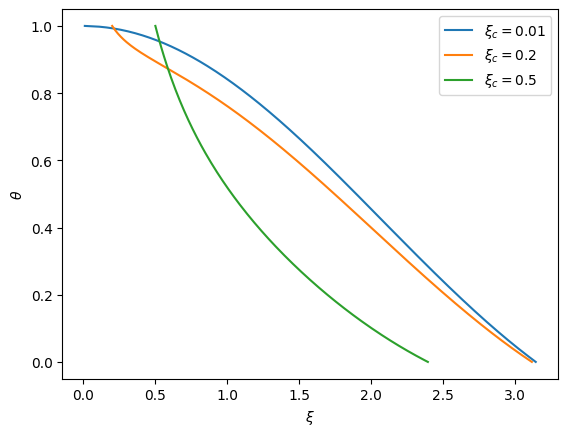

In [51]:
rho_i = 0.1
xi_cs = [0.01, 0.2, 0.5]

for xi_c in xi_cs:
    xi, theta, mass = solve(xi_c, rho_i, fine_grained=True)
    plt.plot(xi, theta, label=r'$\xi_c=${}'.format(xi_c))

plt.xlabel(r'$\xi$')
plt.ylabel(r'$\theta$')
plt.legend()
plt.show()

## Connecting the planet to the disc

For $n=1$, the solution will always reach zero density at some point. It is natural to define this as the surface of the planet. After all, in the Solar system planets are connected to the vacuum of space. However, during planet formation, the planet is embedded in a gas disc. The density profile of the planet will have to connect to the disc at some point! Therefore, we can not go all the way to zero density. A natural point to make the connection is at the Hill radius of the planet (in the approximation $M_p \ll M_*$):
$$r_H = a_p \left(\frac{M_p}{3M_*}\right)^{1/3},$$
where $a_p$ is the semi-major axis of the orbit of the planet, $M_p$ is the total mass of the planet (core + envelope), and $M_*$ is the mass of the central star (i.e. the Sun). Roughly speaking, within the Hill radius, gravity of the planet dominates, and material is bound to the planet (see FPS section 2.2.3). Outside of the Hill radius, gravity of the Sun dominates, and material will generally orbit the Sun. It therefore seems natural to connect our planet model to a disc at $r=r_H$. A complicating factor is that we don't know in advance what the mass of our planet will be: we have to numerically integrate our equations to get the total mass! 

In dimensionless units, the Hill radius reads
$$\xi_H(\xi) = \xi_c\left(\frac{4\pi \rho_c a_p^3}{9 M_*} \frac{M(\xi)}{M_c}\right)^{1/3}.$$
In order to connect to a disc at a radius $\xi_*$, we need that $\xi_H(\xi_*)=\xi_*$, and in addition the density at $\xi_*$ will have to match the density of the disc. Below, we consider three different core masses at $\rho_i/\rho_c=10^{-5}$. The dotted line indicates $\xi_H=\xi$. Only one model can be connected to *any* disc! 

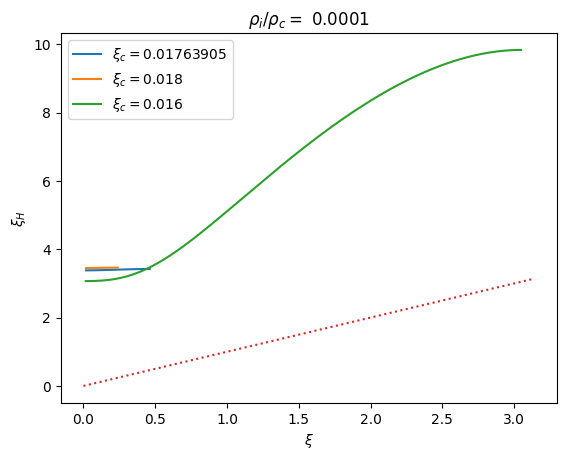

In [ ]:
rho_c = 3000  # kg/m^3
Msun = 1.989e30
AU = 1.496e11
A = 4*np.pi*rho_c*AU*AU*AU/(9*Msun)

rho_i = 0.00001
xi_cs = [0.005, 0.0054, 0.0056]
rho_i = 0.0001
xi_cs = [0.01763905, 0.018, 0.016]

for xi_c in xi_cs:
    xi, theta, mass = solve(xi_c, rho_i, fine_grained=True)
    plt.plot(xi, np.power(A*mass,1./3.)*xi_c, label=r'$\xi_c=${}'.format(xi_c))

plt.title(r'$\rho_i/\rho_c =$ {}'.format(rho_i))
plt.plot([0,np.pi],[0,np.pi], linestyle=':')
plt.xlabel(r'$\xi$')
plt.ylabel(r'$\xi_H$')
plt.legend()
plt.show()


So there are cores which can not be connected to *any* disc at all. In fact, there is only a small range of cores that can be connected to a disc. Below, we explore parameter space for $n=1$. This calculation involves tens of thousands of models, so it may take a while to compute!

/var/folders/pw/1lcr3ydj01v0yp6l13t4dtym0000gn/T/ipykernel_30862/134184180.py:44: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  res1 = fsolve(f, 0.005)[0]


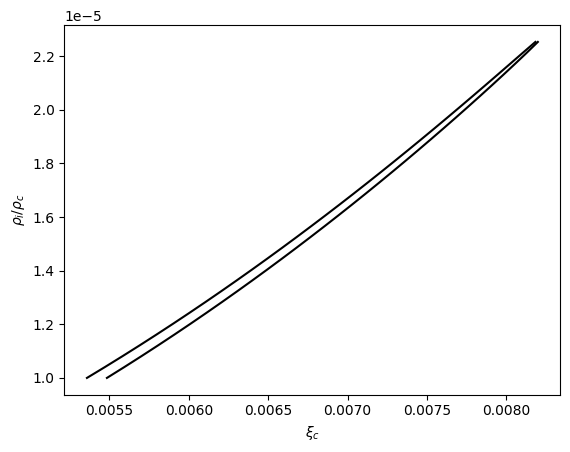

In [ ]:

rho_c = 3000  # kg/m^3
Msun = 1.989e30
AU = 1.496e11
A = 9*Msun/(4*np.pi*rho_c*AU*AU*AU)

def F(xi_c, rho_i):
    xi, theta, mass = solve(xi_c, rho_i, fine_grained=False)
    return xi[-1]**3 - xi_c**3*mass[-1]/A #, xi[-1], mass[-1]


M = 100
rho_i = np.linspace(0.00001, 0.00005, M)
min_xi = []
max_xi = []
valid_rho_min = []
valid_rho_max = []
for j in range(0,M):
    f = lambda x: F(x, rho_i[j])
    res1 = fsolve(f, 0.005)[0]

    if np.isclose(F(res1, rho_i[j]), 0.0):
        valid_rho_min.append(rho_i[j])
        min_xi.append(res1)

        if f(res1+1.0e-8)*f(0.01) < 0.0:
            res2 = root_scalar(f, bracket=[res1 + 1.0e-8, 0.01], method='bisect').root
            valid_rho_max.append(rho_i[j])
            max_xi.append(res2)

        if f(res1-1.0e-8)*f(0.005) < 0.0:
            valid_rho_max.append(rho_i[j])
            max_xi.append(res1)

            res2 = root_scalar(f, bracket=[0.005, res1 - 1.0e-8], method='bisect').root
            min_xi[-1]=res2

        #print(j, , f(0.01))
    else:
        break;

plt.plot(min_xi, valid_rho_min, color='k')
plt.plot(max_xi, valid_rho_max, color='k')
plt.xlabel(r'$\xi_c$')
plt.ylabel(r'$\rho_i/\rho_c$')

plt.show()

#xic = np.linspace(0.005, 0.01, 1000)
#res = np.zeros_like(xic)
#f = lambda x: F(x, 1.020100502512563e-05)
#for i in range(0, len(xic)):
#    res[i] = f(xic[i])
#plt.plot(xic, res)
#plt.show()


Only models within the black contour can connect to a disc. We can read off the maximum value of $\xi_c$ for which we can have a valid model, which corresponds to a maximum core radius $r_c = \xi_c/\alpha$, which in turn corresponds to a maximum core mass $M_c=4\pi r_c^3\rho_c/3$. This is the *critical core mass*, beyond which rapid gas accretion can begin. 